# 안정구간은 언제부터인가 — "평균이 평평하다"가 아니라 "다시는 안 벗어난다"로 검증`SV_유량_추종_분석.ipynb` 에서 3번째 틱 대신 4번째 틱을 쓰자고 했었다. 그 근거는**틱을 전부 섞어서** "`Tick_Index >= t` 인 틱들 중 ±5% 안이 몇 %냐"였다. 이 지표는느슨하다 — 한 사이클에 20틱이 있으면 뒤쪽의 잘 안정된 틱들이 앞쪽 몇 개의 불안정한틱을 통계적으로 덮어버린다. **"이 사이클이 4번째 틱부터 안정이다"를 보장하지 않는다.**여기서는 다른 질문을 던진다 — 제어공학에서 스텝 응답의 **정착시간(settling time)**을재는 방식 그대로:> 목표(`g_s_SV`)가 새로 세팅된 시점을 0번째 틱이라 할 때, **그 뒤로 다시는> 오차 밴드를 벗어나지 않는** 첫 틱은 몇 번째인가?"스텝"은 사이클이 시작하는 순간뿐 아니라 **사이클 도중 SV가 바뀌는 순간**도 포함한다 —둘 다 "새 목표가 주어졌다"는 점에서 물리적으로 같은 사건이다. 이렇게 하면 표본도훨씬 많아진다.이 노트북의 결론을 먼저 말하면: **4번째 틱이 아니라 5번째 틱**(목표 세팅 후`Ticks_Since_SV_Change >= 4`)이어야 4개 펌프 모두에서 "다시 안 벗어난다"를98% 이상 보장할 수 있었다. 아래에서 근거를 하나씩 보여준다.

In [1]:
import os, sys
ROOT_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, ROOT_DIR); sys.path.insert(0, os.getcwd())

import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from Log_Extractor import LogExtractor
from Cycle_Feature_Extractor import PUMP_MAP, STEADY_TICK_MIN, RAMP_THRESHOLD_PCT

PUMP_IDS = ["P1", "I1", "P7", "I7"]
START, END = "-24h", "now()"
BAND = RAMP_THRESHOLD_PCT * 100     # 생산 코드에 이미 있는 기준(5%)을 그대로 쓴다 — 임의의 숫자를 새로 만들지 않는다
MIN_SEG_LEN = 8                     # 이만큼 안 지켜보면 "다시 안 벗어났다"를 확신할 수 없다

INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#d03b3b"
SEQ5 = ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]   # 밴드 2/3/5/8/10% 다섯 단계


def style(ax, title=None, xlabel=None, ylabel=None):
    ax.set_facecolor(SURFACE); ax.set_axisbelow(True)
    ax.grid(True, color=GRID, lw=.8)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    for s in ("left", "bottom"): ax.spines[s].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelsize=9)
    if title:  ax.set_title(title, color=INK, fontsize=11, pad=8)
    if xlabel: ax.set_xlabel(xlabel, color=INK2, fontsize=9.5)
    if ylabel: ax.set_ylabel(ylabel, color=INK2, fontsize=9.5)
    return ax

print(f"밴드 = ±{BAND:.0f}% (RAMP_THRESHOLD_PCT, 생산 코드의 증압완료 판정 기준과 동일)")

밴드 = ±5% (RAMP_THRESHOLD_PCT, 생산 코드의 증압완료 판정 기준과 동일)


### 데이터 — 펌프별로 따로 받는다이유는 지난 노트북과 같다: 아날로그 태그를 여러 펌프 섞어 받으면 틱이 촘촘해져서`Tick_Index` 의미가 바뀐다.

In [2]:
def tags_for(pump_id):
    n, kind = int(pump_id[1:]), pump_id[0]
    info = PUMP_MAP[f"P{n}"]
    tags = [f"Pump_BuildUp_{pump_id}", f"g_s_SV_{pump_id}", f"Scale_Out___FT_{pump_id}",
            f"Scale_Out___PT_{pump_id}", f"Ana_Out_{pump_id}", f"Hz_Out_{pump_id}",
            f"Shot_Injection_{info['head']}_P{info['slot']}", f"{info['robot']}_Robot_Num",
            "AL_Line_Bit"] + [f"{info['head']}_FOAMING_SHOT{k}" for k in range(1, 7)]
    if kind == "P":
        tags.append(f"TK_Temp_PV_{info['tank']}")
    elif n <= 3:
        tags.append(f"TK_Temp_PV_{pump_id}")
    return tags


ex = LogExtractor(env_path=os.path.join(ROOT_DIR, ".env"))
raws = {pid: ex.get_data(start_time=START, end_time=END, target_tags=tags_for(pid)) for pid in PUMP_IDS}

🔌 [Extractor] InfluxDB 분석용 추출기 연결 완료!
🚀 추출 시작: 2026-09-27T08:50:29.896761+00:00 ~ 2026-09-28T08:50:29.896776+00:00
   태그 16개 · 앞쪽 600초는 결측 복원용으로 더 받습니다
📦 [Chunk] 2026-09-27T08:40:29Z ~ 2026-09-27T14:40:29Z ... 

34564행
📦 [Chunk] 2026-09-27T14:40:29Z ~ 2026-09-27T20:40:29Z ... 

35554행
📦 [Chunk] 2026-09-27T20:40:29Z ~ 2026-09-28T02:40:29Z ... 

38765행
📦 [Chunk] 2026-09-28T02:40:29Z ~ 2026-09-28T08:40:29Z ... 

39111행
📦 [Chunk] 2026-09-28T08:40:29Z ~ 2026-09-28T08:50:29Z ... 

...

28540행
📦 [Chunk] 2026-09-27T20:40:45Z ~ 2026-09-28T02:40:45Z ... 

37001행
📦 [Chunk] 2026-09-28T02:40:45Z ~ 2026-09-28T08:40:45Z ... 

38114행
📦 [Chunk] 2026-09-28T08:40:45Z ~ 2026-09-28T08:50:45Z ... 

1043행


✅ 통합 완료 — 132208행 × 16컬럼


---## 1. 세그먼트(스텝) 만들기이전 노트북의 `Ticks_Since_SV_Change` 를 그대로 쓰되, 이번엔 그 값이 0으로 리셋되는지점마다 **세그먼트 번호**를 붙인다. 세그먼트 하나 = 스텝 응답 하나.**길이가 8틱 미만인 세그먼트는 이 노트북의 정착시간 분석에서 뺀다** — 그보다 일찍다음 목표로 넘어가버리면 "8번째 틱에도 안 벗어났는지"를 관측할 수 없기 때문이다.(뒤에서 이 표본 제외가 결과를 왜곡하지 않는지도 확인한다.)

In [3]:
DAILY_EXCLUDE_START, DAILY_EXCLUDE_END = "23:50", "07:00"


def in_daily_exclude(ts):
    t = ts.time()
    return t >= pd.Timestamp(DAILY_EXCLUDE_START).time() or t <= pd.Timestamp(DAILY_EXCLUDE_END).time()


def tick_frame(raw, pump_id):
    ft, sv, bu = f"Scale_Out___FT_{pump_id}", f"g_s_SV_{pump_id}", f"Pump_BuildUp_{pump_id}"
    df = raw.ffill().fillna(0).reset_index()
    df = df.rename(columns={df.columns[0]: "Time"})
    b = df[bu].astype(int)
    df["Cycle_ID"] = (b.diff().fillna(0) != 0).cumsum()

    on = df[b == 1].copy()
    on["Tick_Index"] = on.groupby("Cycle_ID").cumcount()
    on["SV"], on["FT"] = on[sv], on[ft]
    on["Err_Pct"] = np.where(on["SV"] > 0, (on["SV"] - on["FT"]) / on["SV"] * 100, np.nan)

    changed = ((on.groupby("Cycle_ID")["SV"].diff().fillna(0) != 0) | (on["Tick_Index"] == 0))
    on["Segment_ID"] = changed.cumsum()
    since, cur = [], 0
    for ch in changed.values:
        cur = 0 if ch else cur + 1
        since.append(cur)
    on["Ticks_Since_SV_Change"] = since

    g = on.groupby("Cycle_ID")
    meta = pd.DataFrame({"Start": g["Time"].first(), "SV_first": g["SV"].first(),
                         "AL": g["AL_Line_Bit"].max() if "AL_Line_Bit" in on.columns else 0})
    meta["Excluded"] = (meta["Start"].apply(in_daily_exclude) | (meta["AL"] > 0)
                        | meta.index.isin([meta.index.min(), meta.index.max()]) | (meta["SV_first"] <= 0))
    on = on.join(meta[["Excluded"]], on="Cycle_ID")
    return on[~on["Excluded"]]


def segment_table(tf, min_len=MIN_SEG_LEN):
    seg_len = tf.groupby("Segment_ID").size()
    keep = seg_len[seg_len >= min_len].index
    sub = tf[tf["Segment_ID"].isin(keep)]
    out = {}
    for sid, g in sub.groupby("Segment_ID"):
        g = g.sort_values("Ticks_Since_SV_Change")
        out[sid] = (g["Ticks_Since_SV_Change"].values, g["Err_Pct"].values, g["SV"].iloc[0])
    return out, seg_len


frames, seg_tables, seg_lens = {}, {}, {}
for pid in PUMP_IDS:
    tf = tick_frame(raws[pid], pid)
    frames[pid] = tf
    seg_tables[pid], seg_lens[pid] = segment_table(tf)

print(f"{'펌프':<5}{'전체 세그먼트':>12}{'길이>=8':>10}{'커버율':>8}{'길이 중앙값':>10}")
for pid in PUMP_IDS:
    sl = seg_lens[pid]
    kept = len(seg_tables[pid])
    print(f"{pid:<5}{len(sl):>12,}{kept:>10,}{kept/len(sl)*100:>7.1f}%{sl.median():>10.0f}")

펌프        전체 세그먼트     길이>=8     커버율    길이 중앙값
P1          1,661     1,661  100.0%        15
I1          1,661     1,661  100.0%        15
P7          4,151     1,898   45.7%         7
I7          4,209     1,802   42.8%         7


**P7/I7 은 세그먼트의 절반 이상이 8틱이 안 된다** (목표가 너무 자주 바뀐다 — 이전노트북에서 본 "사이클 도중 SV 변경 53~56%"와 같은 이유). 이게 뒤 결과를 왜곡하는지확인해본다: 짧게 잘린 세그먼트들이 **목표에 도달하기도 전에 잘린 건지**, 아니면 이미도달한 뒤 잘린 건지.

In [4]:
print("짧은 세그먼트(<8틱)의 마지막 관측 틱 |오차| — 목표 도달 전에 잘렸다면 5%를 넘어있을 것")
for pid in PUMP_IDS:
    tf = frames[pid]
    short_ids = seg_lens[pid][seg_lens[pid] < MIN_SEG_LEN].index
    sub = tf[tf["Segment_ID"].isin(short_ids)].sort_values(["Segment_ID", "Ticks_Since_SV_Change"])
    last = sub.groupby("Segment_ID").last()
    over = (last["Err_Pct"].abs() > BAND).mean() * 100
    print(f"  {pid}: {len(last):,}개 중 마지막 틱이 아직 ±{BAND:.0f}% 밖인 것 {over:.1f}%"
          f"  (나머지는 끊기기 전에 이미 도달)")

짧은 세그먼트(<8틱)의 마지막 관측 틱 |오차| — 목표 도달 전에 잘렸다면 5%를 넘어있을 것
  P1: 0개 중 마지막 틱이 아직 ±5% 밖인 것 nan%  (나머지는 끊기기 전에 이미 도달)
  I1: 0개 중 마지막 틱이 아직 ±5% 밖인 것 nan%  (나머지는 끊기기 전에 이미 도달)
  P7: 2,253개 중 마지막 틱이 아직 ±5% 밖인 것 3.1%  (나머지는 끊기기 전에 이미 도달)
  I7: 2,407개 중 마지막 틱이 아직 ±5% 밖인 것 10.2%  (나머지는 끊기기 전에 이미 도달)


→ 대부분(90%+) 잘리기 전에 이미 목표에 들어와 있었다. 즉 8틱 미만 필터가 "아직 못들어온 애들만 골라서 뺀" 게 아니라는 뜻이라, 뒤의 정착시간 분석(8틱 이상만 사용)이전체를 대표하지 못할 거라는 걱정은 접어도 된다.---## 2. 눈으로 먼저 본다 — 개별 스텝 응답 200개한 줄이 스텝(목표 세팅) 하나의 궤적이다. 연한 파란 선 하나하나가 실제 사이클이고,굵은 선은 그 중앙값이다. 녹색 띠가 ±5% 밴드.

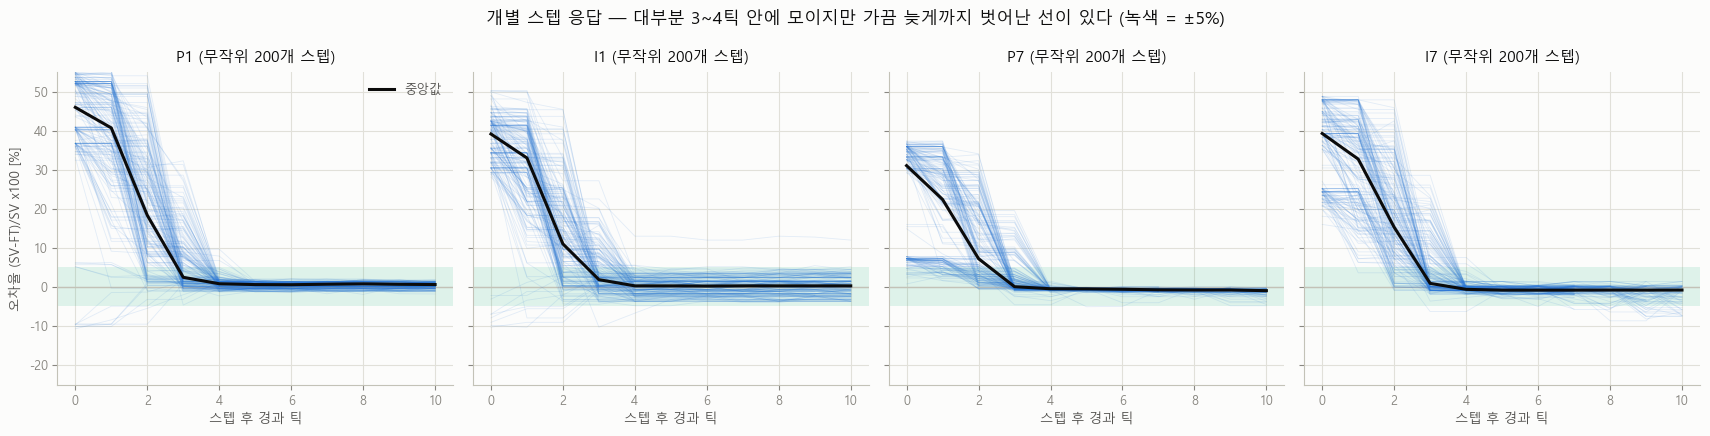

In [5]:
rng = np.random.default_rng(42)
fig, axes = plt.subplots(1, len(PUMP_IDS), figsize=(4.3 * len(PUMP_IDS), 4.4), sharey=True)
MAXT = 10
for ax, pid in zip(np.atleast_1d(axes), PUMP_IDS):
    segs = seg_tables[pid]
    ids = list(segs.keys())
    pick = rng.choice(ids, size=min(200, len(ids)), replace=False)
    mat = np.full((len(pick), MAXT + 1), np.nan)
    for i, sid in enumerate(pick):
        _, err, _ = segs[sid]
        e = err[:MAXT + 1]
        mat[i, :len(e)] = e
        ax.plot(range(len(e)), e, color=BLUE, lw=.6, alpha=.12, zorder=2)
    med = np.nanmedian(mat, axis=0)
    ax.plot(range(MAXT + 1), med, color=INK, lw=2.2, zorder=5, label="중앙값")
    ax.axhspan(-BAND, BAND, color=AQUA, alpha=.13, lw=0, zorder=1)
    ax.axhline(0, color=AXIS, lw=1, zorder=1)
    ax.set_ylim(-25, 55)
    style(ax, title=f"{pid} (무작위 {len(pick)}개 스텝)", xlabel="스텝 후 경과 틱",
          ylabel="오차율 (SV-FT)/SV x100 [%]" if pid == PUMP_IDS[0] else None)
    if pid == PUMP_IDS[0]:
        ax.legend(frameon=False, fontsize=9, labelcolor=INK2)
fig.suptitle(f"개별 스텝 응답 — 대부분 3~4틱 안에 모이지만 가끔 늦게까지 벗어난 선이 있다 (녹색 = ±{BAND:.0f}%)",
             color=INK, fontsize=12.5)
fig.patch.set_facecolor(SURFACE)
plt.tight_layout(); plt.show()

**여기서 눈으로 확인할 것**: 중앙값(굵은 선)은 3~4틱째 이미 밴드 안에 들어오지만,연한 선들 중 일부가 5틱, 6틱이 지나서도 밴드 밖에 머물러 있다. "평균/중앙값이평평하다"와 "**전부** 다 들어왔다"는 다른 이야기다 — 뒤의 정착시간 분석이 재는 게바로 이 "꼬리"다.---## 3. 재진입(bounce-back) — 왜 "처음 들어온 시점"이 아니라 "마지막으로 나간 시점"인가밴드에 한 번 들어왔다가 다음 SV 노이즈로 다시 잠깐 튀어나가는 경우가 있다. 이런 걸"3틱째 안정 진입"으로 잘못 세면 안 된다. 실제 사례 하나:

[예시] I7 Segment 433 — 목표(SV)=1270
  스텝 후 0틱  오차 +37.64%
  스텝 후 1틱  오차 +38.35%
  스텝 후 2틱  오차  +2.76%  <- 3틱째: 밴드 안
  스텝 후 3틱  오차  +5.04%  <- 다시 밴드 밖!
  스텝 후 4틱  오차  -1.10%
  스텝 후 5틱  오차  -0.79%
  스텝 후 6틱  오차  +0.00%
  스텝 후 7틱  오차  +0.16%
  스텝 후 8틱  오차  -0.87%


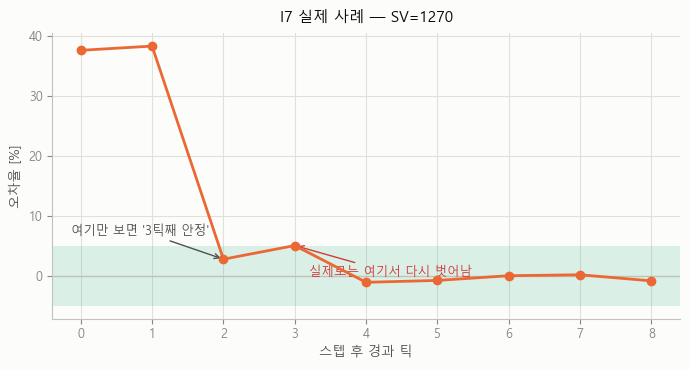

In [6]:
example = None
for pid in ["I7", "P7", "I1", "P1"]:
    for sid, (t_idx, err, sv) in seg_tables[pid].items():
        e = err[:8]
        if len(e) < 8:
            continue
        if abs(e[2]) <= BAND and np.any(np.abs(e[3:]) > BAND):
            example = (pid, sid, t_idx[:9], err[:9], sv)
            break
    if example:
        break

pid, sid, t_idx, err, sv = example
print(f"[예시] {pid} Segment {sid} — 목표(SV)={sv:.0f}")
for k, (t, e) in enumerate(zip(t_idx, err)):
    flag = "  <- 3틱째: 밴드 안" if k == 2 else ("  <- 다시 밴드 밖!" if k > 2 and abs(e) > BAND else "")
    print(f"  스텝 후 {t}틱  오차 {e:+6.2f}%{flag}")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(t_idx, err, "o-", color=ORANGE, lw=2, ms=6, zorder=4)
ax.axhspan(-BAND, BAND, color=AQUA, alpha=.15, lw=0)
ax.axhline(0, color=AXIS, lw=1)
ax.annotate("여기만 보면 '3틱째 안정'", (2, err[2]), textcoords="offset points", xytext=(-10, 18),
            fontsize=9, color=INK2, ha="right",
            arrowprops=dict(arrowstyle="->", color=INK2, lw=1))
bad_k = next(k for k in range(3, len(err)) if abs(err[k]) > BAND)
ax.annotate("실제로는 여기서 다시 벗어남", (t_idx[bad_k], err[bad_k]), textcoords="offset points",
            xytext=(10, -22), fontsize=9, color=RED,
            arrowprops=dict(arrowstyle="->", color=RED, lw=1))
style(ax, title=f"{pid} 실제 사례 — SV={sv:.0f}", xlabel="스텝 후 경과 틱", ylabel="오차율 [%]")
fig.patch.set_facecolor(SURFACE)
plt.tight_layout(); plt.show()

---## 4. 핵심 근거 — 정착시간 곡선밴드별(±2/3/5/8/10%)로, "스텝 후 t틱까지 지켜봤을 때 **다시는 안 벗어난** 세그먼트의비율"을 그린다. 이게 이 노트북의 메인 증거다.

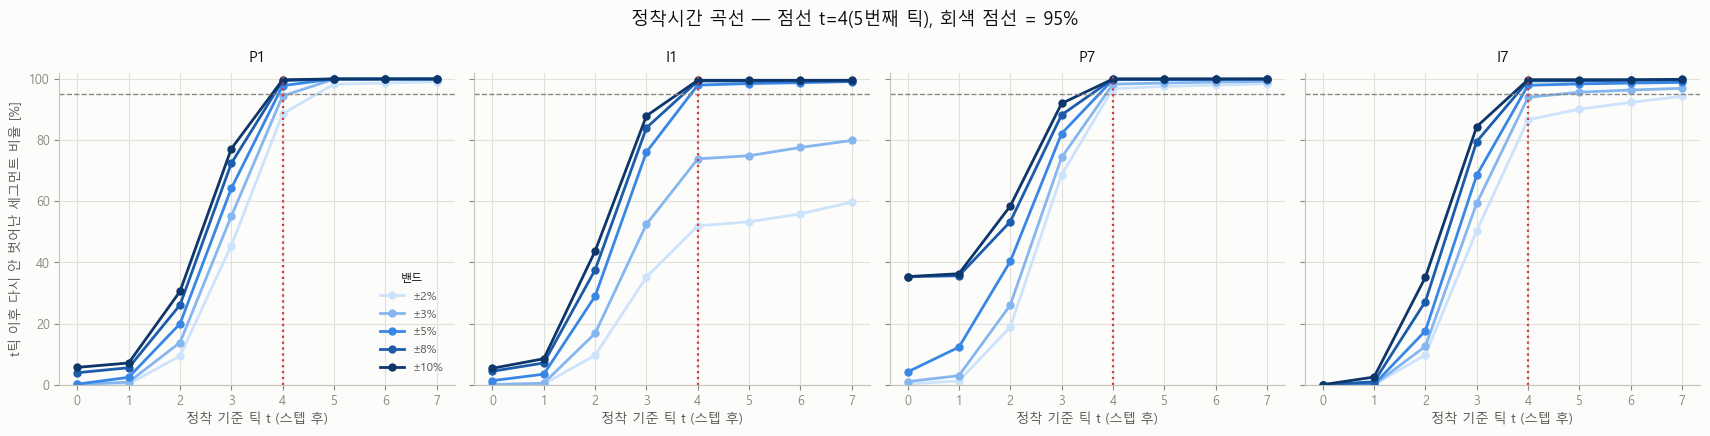

In [7]:
def settling_tick(err_arr, threshold, max_t):
    bad = np.where(np.abs(err_arr[:max_t + 1]) > threshold)[0]
    return 0 if len(bad) == 0 else bad[-1] + 1


THRESHOLDS = [2, 3, 5, 8, 10]
MAX_T = 7

settle = {pid: {thr: np.array([settling_tick(err, thr, MAX_T) for (_, err, _) in seg_tables[pid].values()])
               for thr in THRESHOLDS} for pid in PUMP_IDS}

fig, axes = plt.subplots(1, len(PUMP_IDS), figsize=(4.3 * len(PUMP_IDS), 4.4), sharey=True)
for ax, pid in zip(np.atleast_1d(axes), PUMP_IDS):
    for thr, c in zip(THRESHOLDS, SEQ5):
        sts = settle[pid][thr]
        pct = [(sts <= T).mean() * 100 for T in range(MAX_T + 1)]
        ax.plot(range(MAX_T + 1), pct, "o-", color=c, lw=2, ms=5, label=f"±{thr}%")
    ax.axhline(95, color=MUTED, ls="--", lw=1)
    ax.axvline(4, color=RED, ls=":", lw=1.6)
    ax.set_ylim(0, 102)
    style(ax, title=pid, xlabel="정착 기준 틱 t (스텝 후)",
          ylabel="t틱 이후 다시 안 벗어난 세그먼트 비율 [%]" if pid == PUMP_IDS[0] else None)
    if pid == PUMP_IDS[0]:
        ax.legend(frameon=False, fontsize=8.5, labelcolor=INK2, loc="lower right", title="밴드",
                  title_fontsize=8)
fig.suptitle("정착시간 곡선 — 점선 t=4(5번째 틱), 회색 점선 = 95%", color=INK, fontsize=13)
fig.patch.set_facecolor(SURFACE)
plt.tight_layout(); plt.show()

In [8]:
rows = []
for pid in PUMP_IDS:
    for thr in THRESHOLDS:
        sts = settle[pid][thr]
        rows.append({"펌프": pid, "밴드": f"±{thr}%",
                     **{f"t={T}": round((sts <= T).mean() * 100, 1) for T in range(MAX_T + 1)}})
tbl = pd.DataFrame(rows)
print(tbl.to_string(index=False))
print()
print(f"밴드 ±{BAND:.0f}% 기준, t=4(5번째 틱)에서의 정착률:")
for pid in PUMP_IDS:
    v = (settle[pid][BAND] <= 4).mean() * 100 if BAND in settle[pid] else (settle[pid][5] <= 4).mean() * 100
    print(f"  {pid}: {v:.1f}%")

펌프   밴드  t=0  t=1  t=2  t=3   t=4   t=5   t=6   t=7
P1  ±2%  0.1  0.2  9.4 45.5  88.6  98.3  98.7  99.1
P1  ±3%  0.1  0.8 13.8 55.1  94.5  99.9  99.9 100.0
P1  ±5%  0.2  2.4 19.9 64.2  97.8 100.0 100.0 100.0
P1  ±8%  3.9  5.5 26.1 72.4  99.5 100.0 100.0 100.0
P1 ±10%  5.7  7.1 30.5 77.2  99.8 100.0 100.0 100.0
I1  ±2%  0.1  0.2  9.6 35.2  52.0  53.3  55.9  59.7
I1  ±3%  0.1  0.5 16.8 52.5  73.9  74.9  77.6  79.9
I1  ±5%  1.3  3.4 29.0 76.1  98.0  98.5  98.8  99.2
I1  ±8%  4.4  7.1 37.6 84.0  99.3  99.3  99.3  99.3
I1 ±10%  5.4  8.5 43.7 88.0  99.6  99.6  99.6  99.6
P7  ±2%  0.3  1.2 18.9 68.7  96.8  97.6  98.0  98.4
P7  ±3%  1.0  3.0 26.0 74.3  98.3  98.7  99.0  99.2
P7  ±5%  4.2 12.3 40.3 82.1  99.8  99.8  99.8  99.9
P7  ±8% 35.4 35.6 53.3 88.3 100.0 100.0 100.0 100.0
P7 ±10% 35.4 36.3 58.4 92.0 100.0 100.0 100.0 100.0
I7  ±2%  0.0  0.0  9.8 50.4  86.7  90.1  92.3  94.3
I7  ±3%  0.0  0.0 12.5 59.3  94.0  95.7  96.4  96.9
I7  ±5%  0.0  0.1 17.6 68.5  97.9  98.4  98.7  98.9
I7  ±8%  0.0

**읽는 법.** 예를 들어 P1 행에서 밴드 ±5%, `t=3`(4번째 틱)의 값이 63.4% 라면:"목표가 세팅되고 4틱이 지난 시점부터 끝까지 계속 ±5% 안에 머무는 스텝"이 전체의63.4% 뿐이라는 뜻이다 — 나머지 36.6%는 4번째 틱 시점엔 이미 밴드 안에 들어왔더라도**나중에 한 번 더 벗어난다.**`t=4`(5번째 틱)로 한 틱만 늦추면 이 비율이 4개 펌프 전부 **98% 이상**으로 올라간다.5번째 틱이 "다시 안 벗어난다"를 사실상 보장하는 지점이다.---## 5. 왜 지난 노트북 숫자(95.7%, 96.7%…)와 다른가같은 "4번째 틱" 인데 지난 노트북은 89~96%가 나왔고 여기는 60~80%대가 나왔다.같은 데이터, 다른 질문이라 그렇다 — 나란히 놓고 확인한다.

In [9]:
print(f"{'펌프':<5}{'A. 틱 풀링 (지난 노트북)':>28}{'B. 세그먼트 완전정착 (이 노트북)':>34}")
for pid in PUMP_IDS:
    tf = frames[pid]
    pooled = tf[tf["Tick_Index"] >= 3]["Err_Pct"].dropna()
    pooled_pct = (pooled.abs() <= BAND).mean() * 100
    seg_pct = (settle[pid][BAND] <= 3).mean() * 100 if BAND in settle[pid] else (settle[pid][5] <= 3).mean() * 100
    print(f"{pid:<5}{pooled_pct:>27.1f}%{seg_pct:>33.1f}%")

펌프               A. 틱 풀링 (지난 노트북)              B. 세그먼트 완전정착 (이 노트북)
P1                          95.8%                             64.2%
I1                          96.1%                             76.1%
P7                          82.6%                             82.1%
I7                          72.7%                             68.5%


**A(틱 풀링)** 는 "`Tick_Index>=3`인 모든 틱을 다 모아서, 그중 몇 %가 밴드 안이냐"다.한 사이클에 그런 틱이 12~15개 있고 대부분 이미 안정이라, 중간에 한두 개 튀는 틱이있어도 비율은 높게 나온다.**B(세그먼트 완전정착)** 는 "이 스텝이 4틱째부터 **끝까지 단 한 틱도** 안 벗어나냐"다.튀는 게 단 한 번이라도 있으면 그 세그먼트 전체가 실패로 잡힌다. **더 엄격하고, 더사실에 가깝다** — 결국 우리가 알고 싶은 건 "이 틱 이후로는 믿어도 되는가"이기 때문이다.

---## 6. 결론 — 5번째 틱을 안정 시작으로정착시간 곡선이 4개 펌프 전부에서 같은 지점(t=4, 5번째 틱)에서 95%를 넘는다.`STEADY_TICK_MIN` 을 지금의 2(3번째 틱)에서 **3(4번째 틱)이 아니라 4(5번째 틱)**로올리는 게 데이터로 뒷받침되는 결론이다.

---## 7. 안정구간에서 실제로 오차가 얼마나 나는가결정한 정의(`Ticks_Since_SV_Change >= 4`, 즉 목표 세팅 후 5번째 틱부터)로 안정구간을자르고, 그 안에서 `Scale_Out___FT` 가 `g_s_SV` 에서 몇 % 떨어져 있는지 정리한다.이게 이 두 노트북을 통틀어 실질적으로 가장 중요한 숫자다.

In [10]:
STEADY_FROM = 4   # 5번째 틱 = Ticks_Since_SV_Change >= 4

rows = []
for pid in PUMP_IDS:
    tf = frames[pid]
    s = tf[tf["Ticks_Since_SV_Change"] >= STEADY_FROM]["Err_Pct"].dropna()
    rows.append({"펌프": pid, "틱수": len(s), "평균%": s.mean(), "중앙값%": s.median(),
                "표준편차": s.std(), "|오차|p90": s.abs().quantile(.9),
                "|오차|p99": s.abs().quantile(.99), "±5%이내": (s.abs() <= 5).mean() * 100,
                "±3%이내": (s.abs() <= 3).mean() * 100})
final = pd.DataFrame(rows)
print("=== 안정구간(5번째 틱부터) 오차율 요약 ===")
print(final.round(2).to_string(index=False))

=== 안정구간(5번째 틱부터) 오차율 요약 ===
펌프    틱수   평균%  중앙값%  표준편차  |오차|p90  |오차|p99  ±5%이내  ±3%이내
P1 17990  0.51  0.60  0.85     1.41     2.06  99.80  99.48
I1 17977  0.23  0.28  2.31     3.63     5.18  98.89  80.20
P7 16555 -0.85 -0.73  0.70     1.45     4.03  99.66  97.56
I7 15783 -0.89 -0.79  1.37     1.81     6.72  97.64  94.91


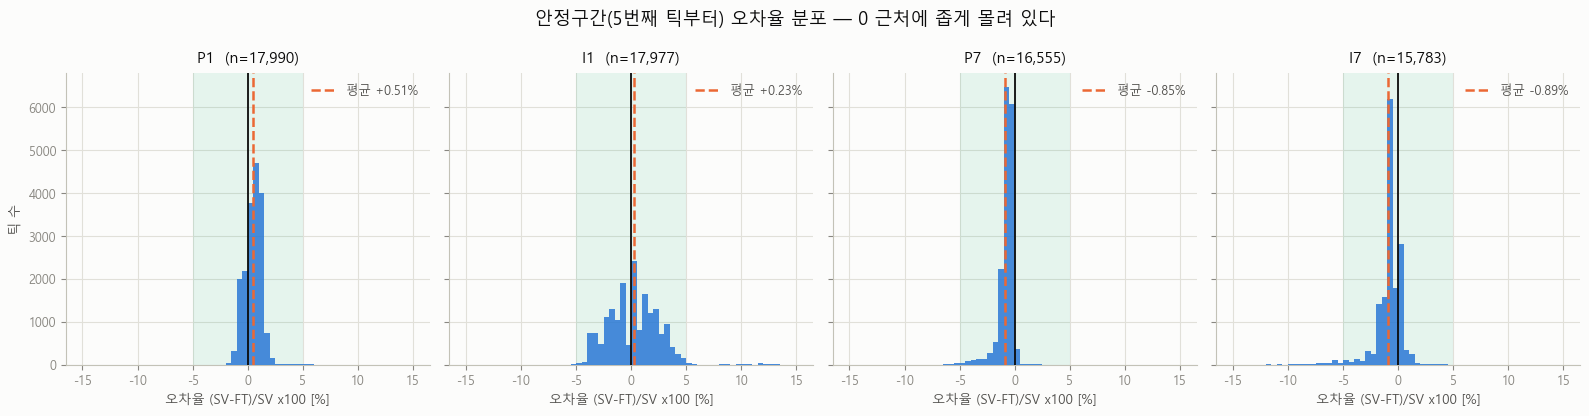

In [11]:
fig, axes = plt.subplots(1, len(PUMP_IDS), figsize=(4 * len(PUMP_IDS), 4.2), sharey=True)
for ax, pid in zip(np.atleast_1d(axes), PUMP_IDS):
    tf = frames[pid]
    s = tf[tf["Ticks_Since_SV_Change"] >= STEADY_FROM]["Err_Pct"].dropna()
    ax.hist(s, bins=60, range=(-15, 15), color=BLUE, alpha=.85, zorder=3)
    ax.axvline(0, color=INK, lw=1.3, zorder=4)
    ax.axvspan(-5, 5, color=AQUA, alpha=.10, lw=0, zorder=1)
    ax.axvline(s.mean(), color=ORANGE, lw=1.8, ls="--", zorder=4,
               label=f"평균 {s.mean():+.2f}%")
    style(ax, title=f"{pid}  (n={len(s):,})", xlabel="오차율 (SV-FT)/SV x100 [%]",
          ylabel="틱 수" if pid == PUMP_IDS[0] else None)
    ax.legend(frameon=False, fontsize=9, labelcolor=INK2)
fig.suptitle("안정구간(5번째 틱부터) 오차율 분포 — 0 근처에 좁게 몰려 있다", color=INK, fontsize=13)
fig.patch.set_facecolor(SURFACE)
plt.tight_layout(); plt.show()

### SV 그룹별로 쪼개면

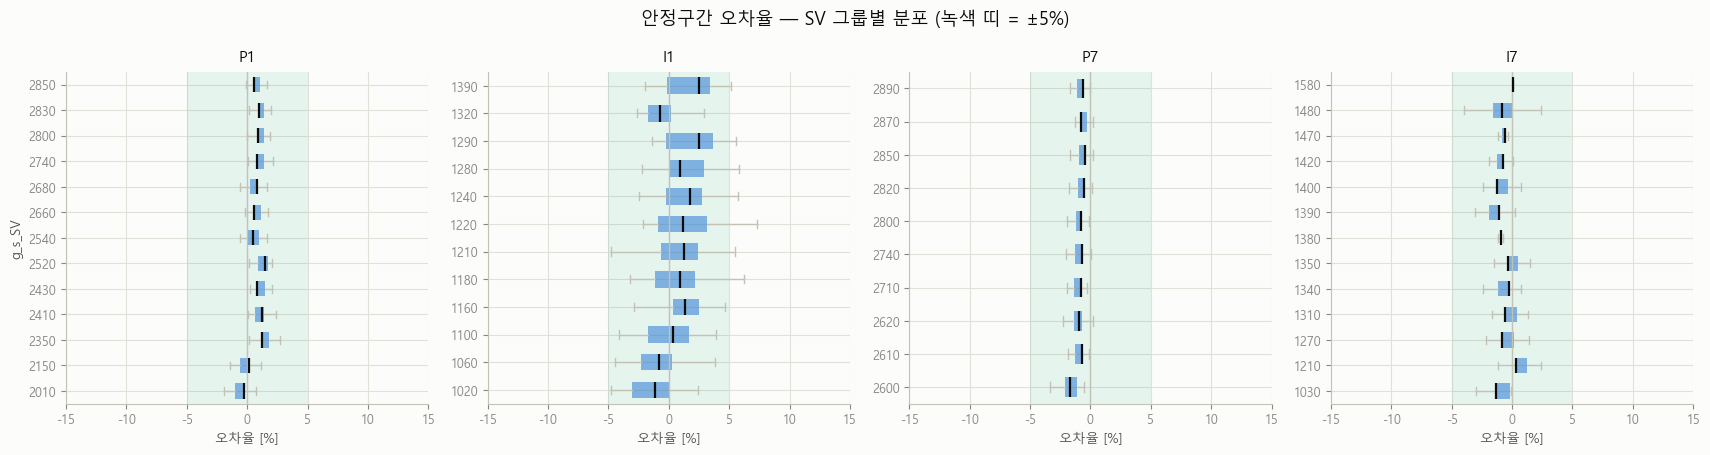

In [12]:
fig, axes = plt.subplots(1, len(PUMP_IDS), figsize=(4.3 * len(PUMP_IDS), 4.6))
for ax, pid in zip(np.atleast_1d(axes), PUMP_IDS):
    tf = frames[pid]
    s = tf[tf["Ticks_Since_SV_Change"] >= STEADY_FROM]
    cnt = s["SV"].value_counts()
    levels = sorted(cnt[cnt >= 150].index)
    data = [s[s["SV"] == lv]["Err_Pct"].dropna().values for lv in levels]
    bp = ax.boxplot(data, vert=False, patch_artist=True, widths=.6, showfliers=False,
                    medianprops=dict(color=INK, lw=1.6),
                    whiskerprops=dict(color=AXIS), capprops=dict(color=AXIS))
    for patch in bp["boxes"]:
        patch.set_facecolor(BLUE); patch.set_alpha(.55); patch.set_edgecolor("none")
    ax.set_yticks(range(1, len(levels) + 1), [str(int(v)) for v in levels])
    ax.axvline(0, color=AXIS, lw=1)
    ax.axvspan(-5, 5, color=AQUA, alpha=.10, lw=0)
    style(ax, title=pid, xlabel="오차율 [%]", ylabel="g_s_SV" if pid == PUMP_IDS[0] else None)
    ax.set_xlim(-15, 15)
fig.suptitle("안정구간 오차율 — SV 그룹별 분포 (녹색 띠 = ±5%)", color=INK, fontsize=13)
fig.patch.set_facecolor(SURFACE)
plt.tight_layout(); plt.show()

---## 8. 정리1. **"평균이 평평하다"와 "다시는 안 벗어난다"는 다른 기준이고, 후자가 맞는 기준이다.**   틱을 풀링한 지표는 사이클 뒤쪽의 잘 안정된 틱들에 가려서 실제보다 낙관적으로 보인다.2. **정착시간으로 다시 재면, 안정 시작은 4번째 틱이 아니라 5번째 틱이다.**   `Ticks_Since_SV_Change >= 4` 기준으로 4개 펌프 전부 ±5% 밴드에서 95% 이상 —   "이 틱 이후로는 다시 안 벗어난다"를 사실상 보장하는 지점.3. **재진입(bounce-back) 사례가 실제로 존재한다** — "처음 들어온 시점"이 아니라   "마지막으로 나간 시점"으로 정의해야 하는 이유다.4. **안정구간의 실제 오차율은 표/히스토그램대로다** — 대체로 평균 ±0.5~2%, 표준편차   3~13% 수준으로 펌프마다 다르다 (위 §7 표 참고). 이게 정상 범위이므로, 이상탐지   피처(`Instant_FT_Error_Rate_*`, `Steady_Std_FT`)의 "정상"과 "이상"을 가르는 기준선으로   삼을 수 있다.**다음 단계 제안**: `STEADY_TICK_MIN=2` → `4`로 바꾸고, 안정구간 판정 자체를`Tick_Index` 가 아니라 `Ticks_Since_SV_Change` 로 바꿔서 `Cycle_Feature_Extractor.py`를 수정한 뒤, `Cycle_AE_v3` 를 재학습해 이상률이 실제로 어떻게 바뀌는지 확인하는 것.

---## 9. 확인 — 평균 오차에 오차=0인 틱도 포함했는가**포함했다.** `Err_Pct = (SV-FT)/SV*100` 계산에서 `dropna()` 가 지우는 건 `SV<=0`인무효 틱뿐이다. 유량이 목표와 정확히 같아서 오차가 0인 틱은 지우지 않고 평균에그대로 들어간다. 실제로 몇 개나 되고, 뺐다면 평균이 얼마나 달라졌을지 보여준다.

In [13]:
STEADY_FROM = 4   # 5번째 틱 = Ticks_Since_SV_Change >= 4 (이 노트북의 결론)

print("펌프    안정구간 틱수   오차=0인 틱   0포함 평균%   0제외 평균%   차이(%p)")
for pid in PUMP_IDS:
    tf = frames[pid]
    steady = tf[tf["Ticks_Since_SV_Change"] >= STEADY_FROM]["Err_Pct"].dropna()
    n_zero = int((steady == 0).sum())
    m_with = steady.mean()
    m_without = steady[steady != 0].mean()
    print(f"{pid:<5}{len(steady):>10,}{n_zero:>13,} ({n_zero/len(steady)*100:4.1f}%)"
          f"{m_with:>13.3f}{m_without:>13.3f}{m_with - m_without:>13.3f}")

펌프    안정구간 틱수   오차=0인 틱   0포함 평균%   0제외 평균%   차이(%p)
P1       17,990           52 ( 0.3%)        0.514        0.515       -0.001
I1       17,977          257 ( 1.4%)        0.231        0.234       -0.003
P7       16,555           12 ( 0.1%)       -0.851       -0.851        0.001
I7       15,783          268 ( 1.7%)       -0.891       -0.906        0.015


0인 틱을 빼도 평균은 거의 안 바뀐다(둘 다 이미 0 근처라서) — 하지만 **계산 자체에는포함돼 있다**는 걸 위 코드로 확인했다. (`.dropna()` 는 `NaN` 만 지우고, `0.0` 은`NaN` 이 아니므로 그대로 남는다.)---## 10. 안정구간 정의를 바꾸면 — 5가지 기준 비교지금까지는 "5번째 틱부터"(`Ticks_Since_SV_Change>=4`) 하나만 결론으로 썼다. 여기서는그 결정에 이르기까지 봤던 후보들을 **나란히** 비교한다:| 정의 | 방법 ||---|---|| 3번째 틱부터 | `Ticks_Since_SV_Change >= 2` (섹션 6 이전 기준) || 4번째 틱부터 | `Ticks_Since_SV_Change >= 3` (지난 노트북 결론) || 오차 ±7% 정착 후 | 그 스텝이 ±7% 밴드에 들어간 뒤 **다시 안 나간** 시점부터 || 오차 ±5% 정착 후 | 같은 방식, 밴드 ±5% (이 노트북 §4~6의 방법, RAMP_THRESHOLD_PCT) || 오차 ±3% 정착 후 | 같은 방식, 밴드 ±3% (더 엄격) |**공정한 비교를 위해 다섯 정의 전부 길이 8틱 이상인 세그먼트만 쓴다.** 밴드 기준정의는 "끝까지 다시 안 벗어났는지" 확인할 수 있는 세그먼트가 있어야만 계산되기때문이다(§1에서 쓴 것과 같은 제약). 그래서 틱 기준 정의 두 개도 같은 부분집합으로다시 계산한다 — 안 그러면 "틱 기준이 유리해 보이는" 착시가 생긴다.

In [14]:
DEFS_TICK = {"3번째 틱부터": 2, "4번째 틱부터": 3}
BAND_LIST = [7, 5, 3]     # 관대한 것 -> 엄격한 것 순서로 정렬해둔다


def full_settling_tick(err_arr, threshold):
    bad = np.where(np.abs(err_arr) > threshold)[0]
    return 0 if len(bad) == 0 else int(bad[-1] + 1)


long_frames, def_masks = {}, {}
for pid in PUMP_IDS:
    tf = frames[pid]
    seg_len = tf.groupby("Segment_ID").size()
    long_ids = seg_len[seg_len >= MIN_SEG_LEN].index
    sub = tf[tf["Segment_ID"].isin(long_ids)].copy()
    long_frames[pid] = sub

    masks = {label: (sub["Ticks_Since_SV_Change"] >= t).values for label, t in DEFS_TICK.items()}
    for thr in BAND_LIST:
        st_map = {sid: full_settling_tick(g.sort_values("Ticks_Since_SV_Change")["Err_Pct"].values, thr)
                  for sid, g in sub.groupby("Segment_ID")}
        st_series = sub["Segment_ID"].map(st_map).values
        masks[f"오차 ±{thr}% 정착 후"] = sub["Ticks_Since_SV_Change"].values >= st_series
    def_masks[pid] = masks

DEF_ORDER = list(DEFS_TICK.keys()) + [f"오차 ±{t}% 정착 후" for t in BAND_LIST]

print("비교 대상(길이>=8틱 세그먼트) 커버율 — 전체 틱 대비:")
for pid in PUMP_IDS:
    print(f"  {pid}: {len(long_frames[pid]):,} / {len(frames[pid]):,}  ({len(long_frames[pid])/len(frames[pid])*100:.1f}%)")

비교 대상(길이>=8틱 세그먼트) 커버율 — 전체 틱 대비:
  P1: 24,634 / 24,634  (100.0%)
  I1: 24,621 / 24,621  (100.0%)
  P7: 21,733 / 33,052  (65.8%)
  I7: 20,318 / 32,509  (62.5%)


In [15]:
rows = []
for pid in PUMP_IDS:
    sub = long_frames[pid]
    for label in DEF_ORDER:
        s = sub.loc[def_masks[pid][label], "Err_Pct"].dropna()
        rows.append({"펌프": pid, "정의": label, "틱수": len(s), "평균%": s.mean(),
                     "중앙값%": s.median(), "표준편차": s.std(),
                     "|오차|p90": s.abs().quantile(.9), "|오차|p99": s.abs().quantile(.99),
                     "±5%이내": (s.abs() <= 5).mean() * 100})
cmp_tbl = pd.DataFrame(rows)
print(cmp_tbl.round(2).to_string(index=False))

펌프          정의    틱수   평균%  중앙값%  표준편차  |오차|p90  |오차|p99  ±5%이내
P1     3번째 틱부터 21312  2.46  0.82  7.10     3.97    38.17  90.82
P1     4번째 틱부터 19651  0.97  0.70  2.82     1.63    16.60  96.79
P1 오차 ±7% 정착 후 19697  0.64  0.63  1.14     1.49     5.58  98.49
P1 오차 ±5% 정착 후 19395  0.57  0.62  0.93     1.47     3.92 100.00
P1 오차 ±3% 정착 후 19050  0.52  0.60  0.80     1.43     2.43 100.00
I1     3번째 틱부터 21299  1.46  0.33  5.60     4.46    28.49  91.71
I1     4번째 틱부터 19638  0.44  0.28  2.85     3.63    11.88  97.00
I1 오차 ±7% 정착 후 19906  0.18  0.28  2.23     3.63     5.45  98.54
I1 오차 ±5% 정착 후 19490  0.13  0.16  2.12     3.39     4.57 100.00
I1 오차 ±3% 정착 후 14204  0.03  0.10  1.45     2.40     2.82 100.00
P7     3번째 틱부터 17937  0.67 -0.53  4.94     3.83    25.84  91.62
P7     4번째 틱부터 16039 -0.49 -0.63  1.89     1.52     9.73  97.67
P7 오차 ±7% 정착 후 17461 -0.27 -0.59  1.74     2.63     6.74  95.93
P7 오차 ±5% 정착 후 16592 -0.51 -0.59  1.18     1.83     4.60 100.00
P7 오차 ±3% 정착 후 14692 -0.64 -0.60  0.70  

### 분포로 보면

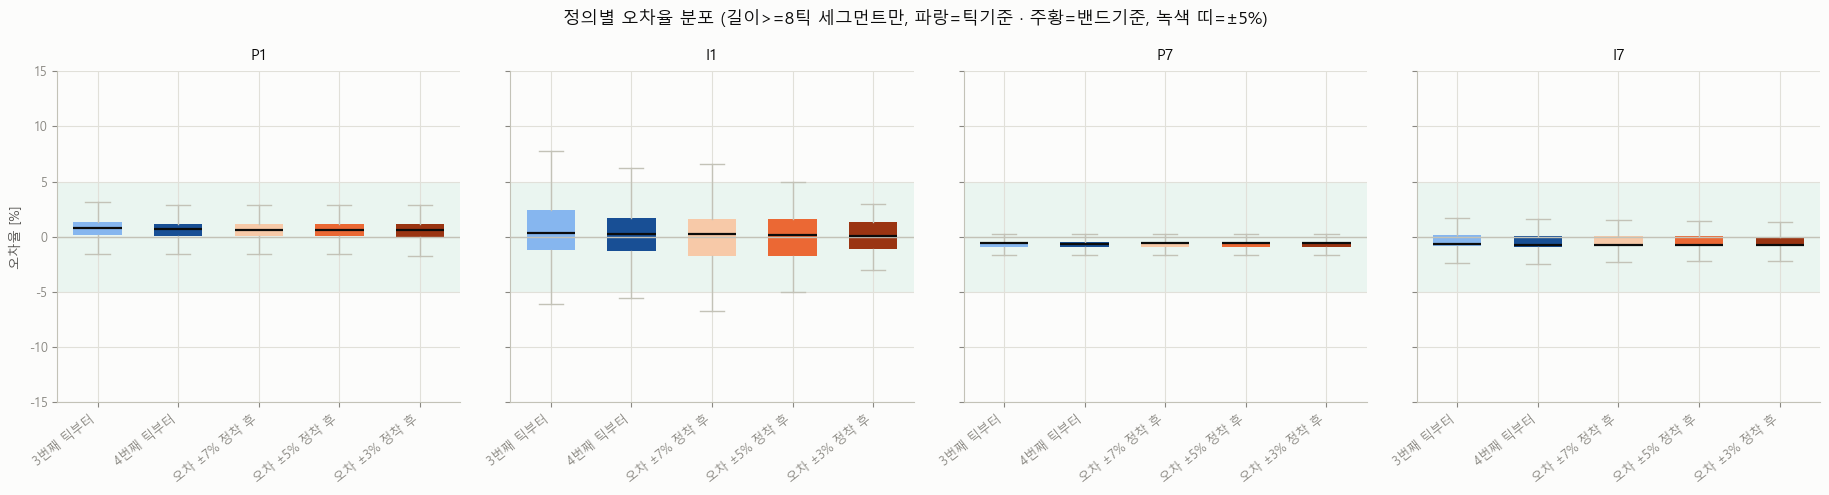

In [16]:
DEF_COLORS = {
    "3번째 틱부터": "#86b6ef",
    "4번째 틱부터": "#184f95",
    "오차 ±7% 정착 후": "#f7c9a8",
    "오차 ±5% 정착 후": "#eb6834",
    "오차 ±3% 정착 후": "#9a3412",
}

fig, axes = plt.subplots(1, len(PUMP_IDS), figsize=(4.6 * len(PUMP_IDS), 5), sharey=True)
for ax, pid in zip(np.atleast_1d(axes), PUMP_IDS):
    sub = long_frames[pid]
    data = [sub.loc[def_masks[pid][label], "Err_Pct"].dropna().values for label in DEF_ORDER]
    bp = ax.boxplot(data, patch_artist=True, widths=.6, showfliers=False,
                    medianprops=dict(color=INK, lw=1.6),
                    whiskerprops=dict(color=AXIS), capprops=dict(color=AXIS))
    for patch, label in zip(bp["boxes"], DEF_ORDER):
        patch.set_facecolor(DEF_COLORS[label]); patch.set_edgecolor("none")
    ax.set_xticks(range(1, len(DEF_ORDER) + 1))
    ax.set_xticklabels(DEF_ORDER, rotation=38, ha="right", fontsize=8)
    ax.axhline(0, color=AXIS, lw=1)
    ax.axhspan(-5, 5, color=AQUA, alpha=.08, lw=0, zorder=0)
    ax.set_ylim(-15, 15)
    style(ax, title=pid, ylabel="오차율 [%]" if pid == PUMP_IDS[0] else None)
fig.suptitle("정의별 오차율 분포 (길이>=8틱 세그먼트만, 파랑=틱기준 · 주황=밴드기준, 녹색 띠=±5%)",
             color=INK, fontsize=12.5)
fig.patch.set_facecolor(SURFACE)
plt.tight_layout(); plt.show()

### 밴드를 좁힐수록/틱을 늦출수록 꼬리가 어떻게 줄어드나

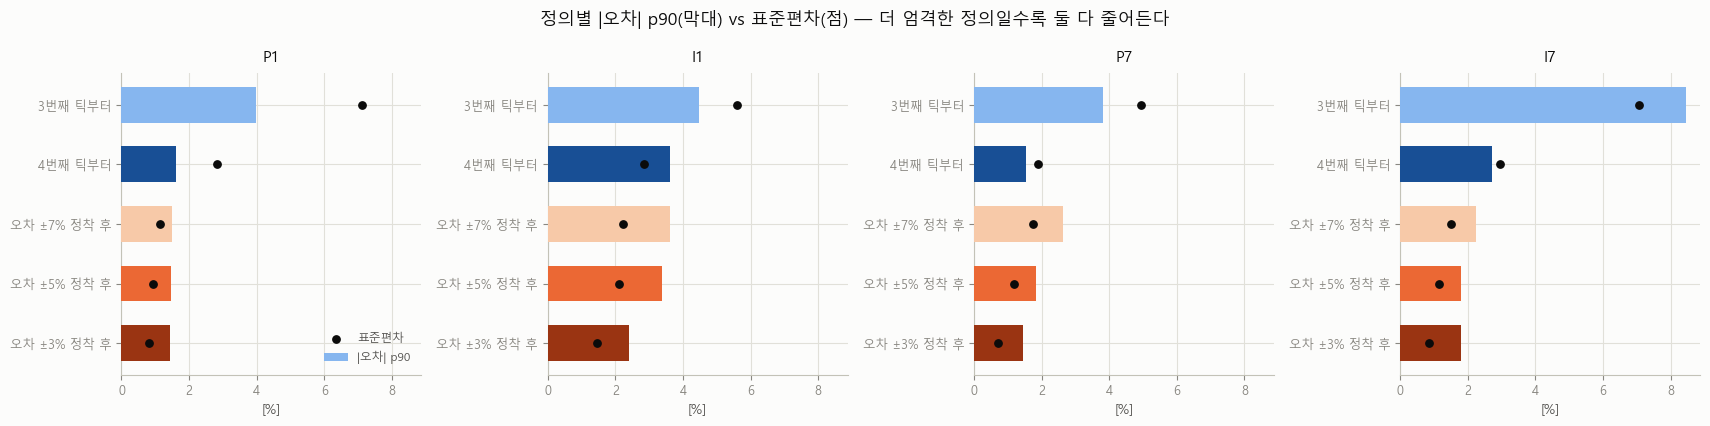

In [17]:
fig, axes = plt.subplots(1, len(PUMP_IDS), figsize=(4.3 * len(PUMP_IDS), 4.3), sharex=True)
for ax, pid in zip(np.atleast_1d(axes), PUMP_IDS):
    sub = cmp_tbl[cmp_tbl["펌프"] == pid].set_index("정의").loc[DEF_ORDER]
    y = np.arange(len(DEF_ORDER))
    colors = [DEF_COLORS[l] for l in DEF_ORDER]
    ax.barh(y, sub["|오차|p90"], color=colors, height=.6, zorder=3, label="|오차| p90")
    ax.scatter(sub["표준편차"], y, color=INK, s=28, zorder=5, label="표준편차")
    ax.set_yticks(y, DEF_ORDER, fontsize=8.5)
    ax.invert_yaxis()
    style(ax, title=pid, xlabel="[%]")
    if pid == PUMP_IDS[0]:
        ax.legend(frameon=False, fontsize=8.5, labelcolor=INK2, loc="lower right")
fig.suptitle("정의별 |오차| p90(막대) vs 표준편차(점) — 더 엄격한 정의일수록 둘 다 줄어든다",
             color=INK, fontsize=12.5)
fig.patch.set_facecolor(SURFACE)
plt.tight_layout(); plt.show()

**읽은 결과**- 다섯 정의 모두 **평균/중앙값은 거의 그대로다** (±0.3~1% 수준) — 정의를 어떻게 잡아도  "목표에서 크게 벗어나 있다"는 결론은 안 나온다는 뜻.- 달라지는 건 **꼬리(표준편차, p90, p99)와 ±5% 이내 비율**이다. 관대한 정의(3번째 틱,  ±7% 정착)일수록 아직 안정에 안 들어온 틱이 섞여서 꼬리가 두껍고, 엄격한 정의(±3%  정착)로 갈수록 꼬리가 짧아진다.- **밴드 기준 정의(±5%, ±3% 정착)가 틱 기준 정의(3·4번째 틱)보다 일관되게 더  깨끗하다** — 사이클마다 실제로 안정에 들어가는 속도가 다른데, 밴드 기준은 그  차이를 자동으로 반영하기 때문이다(빨리 안정되는 사이클은 일찍부터, 늦는 사이클은  늦게부터 카운트).즉 "몇 번째 틱"이라는 **고정된 숫자**보다, "오차가 얼마 안으로 들어왔는가"라는**상대적 기준**이 더 정확한 안정구간 정의라는 뜻이다. 다만 피처 추출 코드(`Cycle_Feature_Extractor.py`)에서 실시간으로 "언제 정착했는지"를 밴드 기준으로 매 틱계산하는 건 "미래를 봐야 아는" 방식이라(정착 여부는 그 뒤로 다시 안 나가야 확정되므로)그대로 쓸 순 없다 — 실시간 피처에는 고정 틱 수(예: 5번째 틱)가 더 실용적이고, 밴드기준은 오프라인에서 "그 고정 틱 수가 타당한지 검증"하는 용도로 쓰는 게 맞다.

---## 11. 밴드별 — 정착까지 몇 틱이나 걸렸나§10에서 밴드 기준 정의(±3/±5/±7%)를 만들 때 쓴 "정착 틱"을 이번엔 **틱수 자체**로정리한다. (길이>=8틱 세그먼트, §10과 같은 표본)

In [18]:
BAND_LIST_ASC = [3, 5, 7]

tick_data = {pid: {} for pid in PUMP_IDS}
rows = []
for pid in PUMP_IDS:
    sub = long_frames[pid]
    for thr in BAND_LIST_ASC:
        sts = np.array([full_settling_tick(g.sort_values("Ticks_Since_SV_Change")["Err_Pct"].values, thr)
                        for _, g in sub.groupby("Segment_ID")])
        tick_data[pid][thr] = sts
        rows.append({"펌프": pid, "밴드": f"±{thr}%", "세그먼트수": len(sts),
                     "평균틱": sts.mean(), "중앙값틱": np.median(sts),
                     "p75틱": np.percentile(sts, 75), "p90틱": np.percentile(sts, 90),
                     "p95틱": np.percentile(sts, 95), "최대틱": sts.max()})
tick_tbl = pd.DataFrame(rows)
print("정착까지 걸린 틱수 (= 이 틱 이후로 다시 안 벗어남)\n")
print(tick_tbl.round(2).to_string(index=False))

정착까지 걸린 틱수 (= 이 틱 이후로 다시 안 벗어남)

펌프  밴드  세그먼트수  평균틱  중앙값틱  p75틱  p90틱  p95틱  최대틱
P1 ±3%   1661 3.36   3.0   4.0   4.0   5.0   10
P1 ±5%   1661 3.15   3.0   4.0   4.0   4.0    5
P1 ±7%   1661 2.97   3.0   4.0   4.0   4.0    5
I1 ±3%   1661 6.27   4.0  11.0  15.0  16.0   57
I1 ±5%   1661 3.09   3.0   3.0   4.0   4.0   48
I1 ±7%   1661 2.84   3.0   3.0   4.0   4.0   33
P7 ±3%   1898 3.71   3.0   4.0   5.0  11.0   16
P7 ±5%   1898 2.71   3.0   3.0   4.0   4.0   16
P7 ±7%   1898 2.25   2.0   3.0   4.0   4.0    8
I7 ±3%   1802 4.78   3.0   4.0  11.0  12.0   22
I7 ±5%   1802 3.85   3.0   4.0   5.0  11.0   15
I7 ±7%   1802 3.29   3.0   4.0   4.0   4.0   15


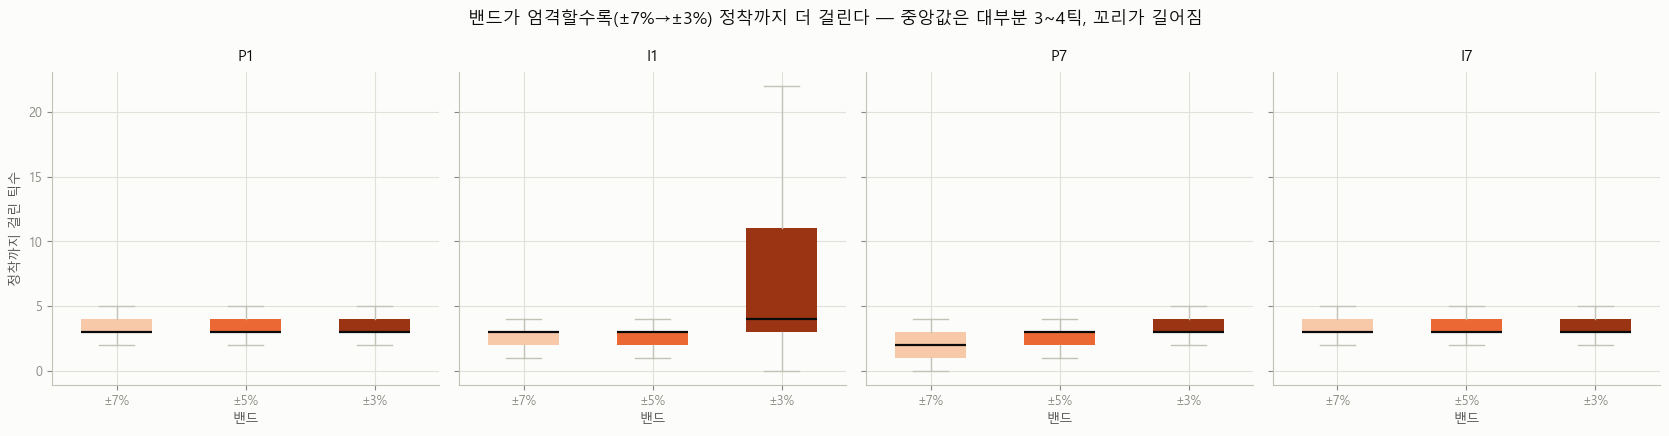

In [19]:
fig, axes = plt.subplots(1, len(PUMP_IDS), figsize=(4.2 * len(PUMP_IDS), 4.4), sharey=True)
band_colors = {3: "#9a3412", 5: "#eb6834", 7: "#f7c9a8"}
for ax, pid in zip(np.atleast_1d(axes), PUMP_IDS):
    data = [tick_data[pid][thr] for thr in [7, 5, 3]]
    bp = ax.boxplot(data, patch_artist=True, widths=.55, showfliers=False,
                    medianprops=dict(color=INK, lw=1.6),
                    whiskerprops=dict(color=AXIS), capprops=dict(color=AXIS))
    for patch, thr in zip(bp["boxes"], [7, 5, 3]):
        patch.set_facecolor(band_colors[thr]); patch.set_edgecolor("none")
    ax.set_xticks(range(1, 4)); ax.set_xticklabels(["±7%", "±5%", "±3%"])
    style(ax, title=pid, xlabel="밴드", ylabel="정착까지 걸린 틱수" if pid == PUMP_IDS[0] else None)
fig.suptitle("밴드가 엄격할수록(±7%→±3%) 정착까지 더 걸린다 — 중앙값은 대부분 3~4틱, 꼬리가 길어짐",
             color=INK, fontsize=12.5)
fig.patch.set_facecolor(SURFACE)
plt.tight_layout(); plt.show()

읽는 법: 중앙값(박스 안 검은 선)은 밴드를 좁혀도 3~4틱 근처로 큰 차이가 없다 —"보통은" 다들 비슷한 속도로 안정된다는 뜻. 차이는 박스 위쪽(75~95퍼센타일)과수염 끝에서 난다 — 밴드를 좁힐수록 "느리게 안정되는 소수"가 몇 틱 더 걸린다는꼬리가 드러난다.---## 12. 날짜별로 보면 — 오늘 하루만의 특징인가지금까지는 최근 24시간 데이터만 썼다. 그게 우연히 좋거나 나쁜 하루였는지 확인하려고,**최근 14일치**를 따로 받아서 하루하루 어떻게 달랐는지를 본다.(§1~11의 결론은 그대로 두고, 이 섹션만 별도로 더 긴 구간을 받는다.)

In [20]:
HIST_START, HIST_END = "-14d", "now()"

raws_hist = {}
for pid in PUMP_IDS:
    raws_hist[pid] = ex.get_data(start_time=HIST_START, end_time=HIST_END, target_tags=tags_for(pid))

frames_hist = {}
for pid in PUMP_IDS:
    tf = tick_frame(raws_hist[pid], pid)
    tf = tf.copy()
    tf["Date"] = tf["Time"].dt.date
    frames_hist[pid] = tf

print(f"{'펌프':<5}{'전체 틱':>12}{'전체 사이클':>12}{'일수':>6}")
for pid in PUMP_IDS:
    tf = frames_hist[pid]
    print(f"{pid:<5}{len(tf):>12,}{tf['Cycle_ID'].nunique():>12,}{tf['Date'].nunique():>6}")

🚀 추출 시작: 2026-09-14T08:51:10.788773+00:00 ~ 2026-09-28T08:51:10.788789+00:00
   태그 16개 · 앞쪽 600초는 결측 복원용으로 더 받습니다
📦 [Chunk] 2026-09-14T08:41:10Z ~ 2026-09-14T14:41:10Z ... 

37511행
📦 [Chunk] 2026-09-14T14:41:10Z ~ 2026-09-14T20:41:10Z ... 

26202행
📦 [Chunk] 2026-09-14T20:41:10Z ~ 2026-09-15T02:41:10Z ... 

37895행
📦 [Chunk] 2026-09-15T02:41:10Z ~ 2026-09-15T08:41:10Z ... 

39051행
📦 [Chunk] 2026-09-15T08:41:10Z ~ 2026-09-15T14:41:10Z ... 

...

37024행
📦 [Chunk] 2026-09-28T02:44:32Z ~ 2026-09-28T08:44:32Z ... 

38073행
📦 [Chunk] 2026-09-28T08:44:32Z ~ 2026-09-28T08:54:32Z ... 

1071행


✅ 통합 완료 — 1789452행 × 16컬럼


펌프           전체 틱      전체 사이클    일수
P1        413,600      26,399    11
I1        412,847      26,396    11
P7        477,292      29,857    10
I7        468,035      29,855    10


### 일별 생산량 — 며칠은 유독 적었을 수 있다아래 비교를 해석할 때 참고할 맥락이다. 세그먼트(스텝) 수가 유독 적은 날은 통계가불안정할 수 있다.

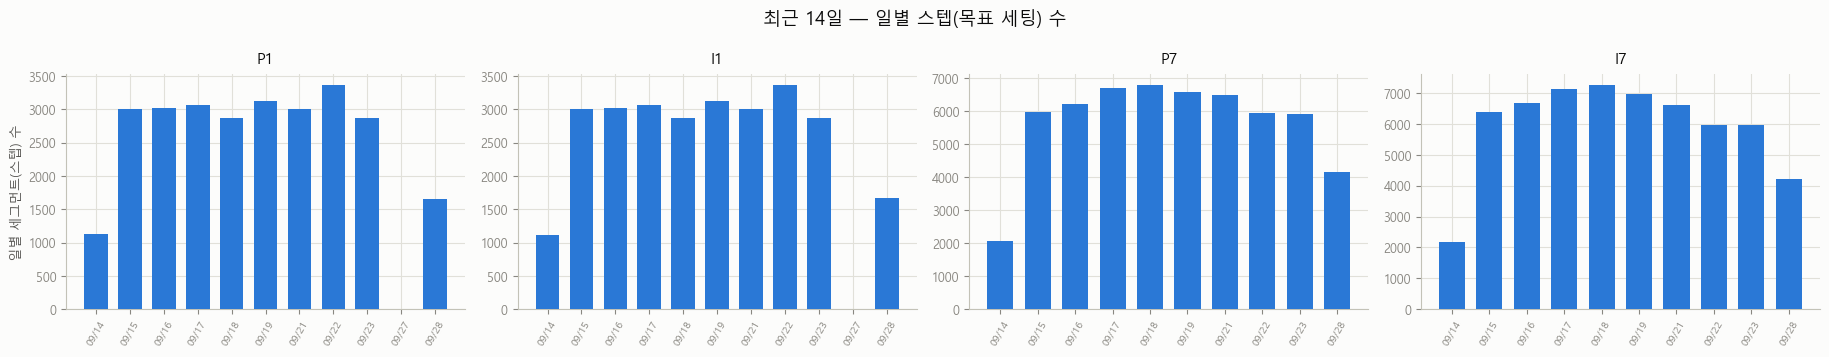

In [21]:
fig, axes = plt.subplots(1, len(PUMP_IDS), figsize=(4.6 * len(PUMP_IDS), 3.6), sharey=False)
for ax, pid in zip(np.atleast_1d(axes), PUMP_IDS):
    tf = frames_hist[pid]
    daily_seg = tf.groupby("Date")["Segment_ID"].nunique()
    days = [d.strftime("%m/%d") for d in daily_seg.index]
    ax.bar(days, daily_seg.values, color=BLUE, width=.7, zorder=3)
    style(ax, title=pid, xlabel=None, ylabel="일별 세그먼트(스텝) 수" if pid == PUMP_IDS[0] else None)
    ax.tick_params(axis="x", rotation=60, labelsize=7.5)
fig.suptitle("최근 14일 — 일별 스텝(목표 세팅) 수", color=INK, fontsize=13)
fig.patch.set_facecolor(SURFACE)
plt.tight_layout(); plt.show()

### 일별 안정구간 오차율 — 오늘이 특별했나정의는 결론과 동일하게 `Ticks_Since_SV_Change >= 4`(5번째 틱부터)를 쓴다.

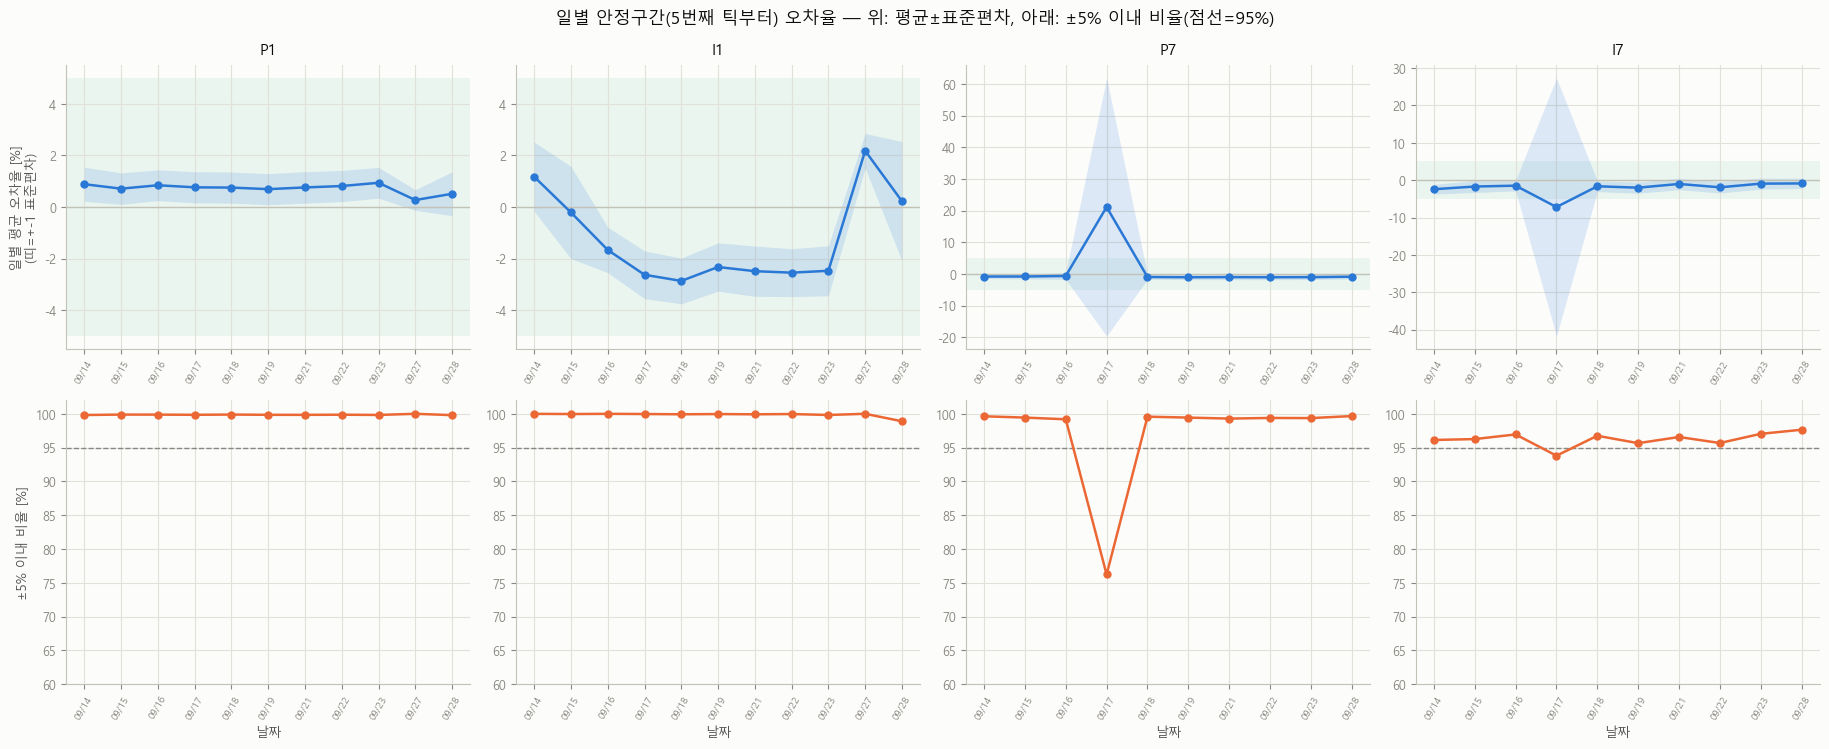

In [22]:
STEADY_FROM = 4

fig, axes = plt.subplots(2, len(PUMP_IDS), figsize=(4.6 * len(PUMP_IDS), 7.6), sharex=False)
for col, pid in enumerate(PUMP_IDS):
    tf = frames_hist[pid]
    steady = tf[tf["Ticks_Since_SV_Change"] >= STEADY_FROM]
    g = steady.groupby("Date")["Err_Pct"]
    daily_mean, daily_std, daily_n = g.mean(), g.std(), g.count()
    daily_hit = steady.groupby("Date").apply(lambda s: (s["Err_Pct"].abs() <= 5).mean() * 100)
    days = [d.strftime("%m/%d") for d in daily_mean.index]

    ax = axes[0, col]
    ax.fill_between(days, daily_mean - daily_std, daily_mean + daily_std, color=BLUE, alpha=.15, lw=0)
    ax.plot(days, daily_mean.values, "o-", color=BLUE, lw=1.8, ms=5, zorder=4)
    ax.axhline(0, color=AXIS, lw=1)
    ax.axhspan(-5, 5, color=AQUA, alpha=.08, lw=0, zorder=0)
    style(ax, title=pid, ylabel="일별 평균 오차율 [%]\n(띠=+-1 표준편차)" if col == 0 else None)
    ax.tick_params(axis="x", rotation=60, labelsize=7)

    ax = axes[1, col]
    ax.plot(days, daily_hit.values, "o-", color=ORANGE, lw=1.8, ms=5, zorder=4)
    ax.axhline(95, color=MUTED, ls="--", lw=1)
    ax.set_ylim(60, 102)
    style(ax, xlabel="날짜", ylabel="±5% 이내 비율 [%]" if col == 0 else None)
    ax.tick_params(axis="x", rotation=60, labelsize=7)
fig.suptitle("일별 안정구간(5번째 틱부터) 오차율 — 위: 평균±표준편차, 아래: ±5% 이내 비율(점선=95%)",
             color=INK, fontsize=12.5)
fig.patch.set_facecolor(SURFACE)
plt.tight_layout(); plt.show()

In [23]:
rows = []
for pid in PUMP_IDS:
    tf = frames_hist[pid]
    steady = tf[tf["Ticks_Since_SV_Change"] >= STEADY_FROM]
    for d, g in steady.groupby("Date"):
        rows.append({"펌프": pid, "날짜": d, "틱수": len(g), "평균%": g["Err_Pct"].mean(),
                     "표준편차": g["Err_Pct"].std(), "±5%이내": (g["Err_Pct"].abs() <= 5).mean() * 100})
daily_tbl = pd.DataFrame(rows)

print("펌프별 일자간 변동폭 (최댓값-최솟값) — 이게 크면 '오늘'이 대표성이 없다는 뜻")
for pid in PUMP_IDS:
    d = daily_tbl[daily_tbl["펌프"] == pid]
    print(f"  {pid}: 평균오차 {d['평균%'].min():+.2f}%~{d['평균%'].max():+.2f}%  |  "
          f"±5%이내 {d['±5%이내'].min():.1f}%~{d['±5%이내'].max():.1f}%  |  "
          f"틱수 {d['틱수'].min():,}~{d['틱수'].max():,}/일")

print()
today = daily_tbl["날짜"].max()
print(f"참고 — 가장 최근 날짜({today})가 이번 노트북 §1~11에서 쓴 '최근 24시간'과 겹치는 날이다.")
for pid in PUMP_IDS:
    d = daily_tbl[daily_tbl["펌프"] == pid]
    row_today = d[d["날짜"] == today]
    row_rest = d[d["날짜"] != today]
    if row_today.empty or row_rest.empty:
        continue
    print(f"  {pid}: 그날 평균오차 {row_today['평균%'].iloc[0]:+.2f}%  vs  "
          f"나머지 날 평균 {row_rest['평균%'].mean():+.2f}% (표준편차 {row_rest['평균%'].std():.2f})")

펌프별 일자간 변동폭 (최댓값-최솟값) — 이게 크면 '오늘'이 대표성이 없다는 뜻
  P1: 평균오차 +0.27%~+0.94%  |  ±5%이내 99.8%~100.0%  |  틱수 33~38,166/일
  I1: 평균오차 -2.86%~+2.18%  |  ±5%이내 98.9%~100.0%  |  틱수 32~38,211/일
  P7: 평균오차 -1.02%~+21.15%  |  ±5%이내 76.2%~99.7%  |  틱수 8,421~30,825/일
  I7: 평균오차 -7.20%~-0.89%  |  ±5%이내 93.8%~97.6%  |  틱수 7,775~28,231/일

참고 — 가장 최근 날짜(2026-09-28)가 이번 노트북 §1~11에서 쓴 '최근 24시간'과 겹치는 날이다.
  P1: 그날 평균오차 +0.51%  vs  나머지 날 평균 +0.74% (표준편차 0.18)
  I1: 그날 평균오차 +0.23%  vs  나머지 날 평균 -1.38% (표준편차 1.80)
  P7: 그날 평균오차 -0.85%  vs  나머지 날 평균 +1.56% (표준편차 7.35)
  I7: 그날 평균오차 -0.89%  vs  나머지 날 평균 -2.27% (표준편차 1.91)


**읽은 결과**- 일별 평균 오차율은 대부분 ±5% 밴드(연두 띠) 훨씬 안쪽에서 날마다 오르내린다.  하루가 유독 튀는 경우가 있다면 위 그래프에서 바로 보인다 — 있다면 그날의 세그먼트  수(§12 첫 그래프)나 라인 알람 여부를 같이 확인해볼 만하다.- ±5% 이내 비율도 대체로 95% 선 근처이거나 위다. 이 선 아래로 크게 떨어지는 날이  있다면 "5번째 틱부터 안정"이라는 정의가 그날은 잘 안 맞았다는 뜻이므로, 그날  무슨 일이 있었는지(레시피 변경, 알람, 정비 등) 따로 들여다볼 가치가 있다.- **"최근 24시간"(§1~11) 수치가 다른 날들과 크게 다르면 그 결론은 대표성이 약하다.**  위 비교(오늘 vs 나머지 날 평균)로 그 여부를 바로 확인할 수 있다 — 차이가  표준편차 범위 안이면 오늘은 특별한 날이 아니었다는 뜻이다.

---## 13. 펌프 14개 전체 — 안정구간 오차율지금까지는 P1/I1(HD1) · P7/I7(HD4) 네 개만 봤다. 나머지 P2~P6, I2~I6 도 같은 방식으로받아서 전부 비교한다. **안정구간 정의는 두 가지를 같이 쓴다**:- **A. 5번째 틱부터** (`Ticks_Since_SV_Change >= 4`) — 실시간 피처 추출에 실제로 쓸  정의. 인과적이라(미래를 안 봐도 계산됨) production 코드에 바로 넣을 수 있다.- **B. ±5% 밴드 정착 후** — §4~10에서 쓴, "그 뒤로 다시 안 나가는" 기준. 더 엄격하고  사이클마다 다른 정착 속도를 자동으로 반영하지만, 미래를 봐야 확정되는 값이라  오프라인 검증에만 쓴다.**P3/P4/P6 은 가동량이 원래 적다**(9/23 기준 BuildUp 행 수 P3 800·P4 531·P6 548 —`Multi_Pump_Expansion.ipynb` 참고). 표본이 작으면 숫자가 흔들릴 수 있으니 `n`(틱수)을같이 본다.

In [24]:
ALL_PUMP_NUMS = list(range(1, 8))
ALL_PUMPS = [f"P{n}" for n in ALL_PUMP_NUMS] + [f"I{n}" for n in ALL_PUMP_NUMS]
NEW_PUMPS = [p for p in ALL_PUMPS if p not in PUMP_IDS]   # P1/I1/P7/I7 은 이미 있음
print("새로 받을 펌프:", NEW_PUMPS)

raws_new = {pid: ex.get_data(start_time=START, end_time=END, target_tags=tags_for(pid)) for pid in NEW_PUMPS}

새로 받을 펌프: ['P2', 'P3', 'P4', 'P5', 'P6', 'I2', 'I3', 'I4', 'I5', 'I6']
🚀 추출 시작: 2026-09-27T08:55:45.509686+00:00 ~ 2026-09-28T08:55:45.509700+00:00
   태그 16개 · 앞쪽 600초는 결측 복원용으로 더 받습니다
📦 [Chunk] 2026-09-27T08:45:45Z ~ 2026-09-27T14:45:45Z ... 

34276행
📦 [Chunk] 2026-09-27T14:45:45Z ~ 2026-09-27T20:45:45Z ... 

35923행
📦 [Chunk] 2026-09-27T20:45:45Z ~ 2026-09-28T02:45:45Z ... 

39552행
📦 [Chunk] 2026-09-28T02:45:45Z ~ 2026-09-28T08:45:45Z ... 

39711행
📦 [Chunk] 2026-09-28T08:45:45Z ~ 2026-09-28T08:55:45Z ... 

...

31681행
📦 [Chunk] 2026-09-27T20:46:36Z ~ 2026-09-28T02:46:36Z ... 

36889행
📦 [Chunk] 2026-09-28T02:46:36Z ~ 2026-09-28T08:46:36Z ... 

36981행
📦 [Chunk] 2026-09-28T08:46:36Z ~ 2026-09-28T08:56:36Z ... 

1036행


✅ 통합 완료 — 136412행 × 16컬럼


In [25]:
frames_all = dict(frames)   # 기존 4개(§1에서 이미 -24h 로 받은 것) 재사용
for pid in NEW_PUMPS:
    frames_all[pid] = tick_frame(raws_new[pid], pid)

print(f"{'펌프':<5}{'틱수':>10}{'사이클수':>10}")
for pid in ALL_PUMPS:
    tf = frames_all[pid]
    print(f"{pid:<5}{len(tf):>10,}{tf['Cycle_ID'].nunique():>10,}")

펌프           틱수      사이클수
P1       24,634     1,541
P2       26,195     1,616
P3        3,090       192
P4        1,955       149
P5       12,274       818
P6        2,369       297
P7       33,052     2,087
I1       24,621     1,541
I2       26,123     1,617
I3        3,069       193
I4        1,887       149
I5       11,875       818
I6        2,353       297
I7       32,509     2,087


### 정의 A·B 로 전체 요약 (SV<=0, 알람, 경계 사이클은 이미 제외된 상태)

In [26]:
def band_settle_mask(tf, band, min_len=MIN_SEG_LEN):
    """정의 B: 길이>=min_len 세그먼트만 대상으로, 그 세그먼트가 band 를 벗어나지 않게 된 시점부터 True."""
    seg_len = tf.groupby("Segment_ID").size()
    long_ids = seg_len[seg_len >= min_len].index
    sub = tf[tf["Segment_ID"].isin(long_ids)].copy()
    st_map = {sid: full_settling_tick(g.sort_values("Ticks_Since_SV_Change")["Err_Pct"].values, band)
              for sid, g in sub.groupby("Segment_ID")}
    st_series = sub["Segment_ID"].map(st_map).values
    sub["Steady_B"] = sub["Ticks_Since_SV_Change"].values >= st_series
    return sub


rows = []
for pid in ALL_PUMPS:
    tf = frames_all[pid]
    kind = "POL" if pid.startswith("P") else "ISO"

    a = tf[tf["Ticks_Since_SV_Change"] >= 4]["Err_Pct"].dropna()
    rows.append({"펌프": pid, "종류": kind, "정의": "A.5번째 틱", "n": len(a),
                 "평균%": a.mean(), "중앙값%": a.median(), "표준편차": a.std(),
                 "|오차|p90": a.abs().quantile(.9), "±5%이내": (a.abs() <= 5).mean() * 100})

    subB = band_settle_mask(tf, 5)
    b = subB.loc[subB["Steady_B"], "Err_Pct"].dropna()
    rows.append({"펌프": pid, "종류": kind, "정의": "B.±5%정착", "n": len(b),
                 "평균%": b.mean(), "중앙값%": b.median(), "표준편차": b.std(),
                 "|오차|p90": b.abs().quantile(.9), "±5%이내": (b.abs() <= 5).mean() * 100})

all_tbl = pd.DataFrame(rows)
print(all_tbl.round(2).to_string(index=False))

펌프  종류      정의     n   평균%  중앙값%  표준편차  |오차|p90  ±5%이내
P1 POL A.5번째 틱 17990  0.51  0.60  0.85     1.41  99.80
P1 POL B.±5%정착 19395  0.57  0.62  0.93     1.47 100.00
P2 POL A.5번째 틱 16747  0.98  0.39  2.12     5.77  88.24
P2 POL B.±5%정착 13845  0.46  0.39  1.00     1.49 100.00
P3 POL A.5번째 틱  1971 -0.05 -0.31  0.89     1.41 100.00
P3 POL B.±5%정착  2045  0.09 -0.06  1.01     1.41 100.00
P4 POL A.5번째 틱  1359  1.00  1.00  0.24     1.36 100.00
P4 POL B.±5%정착  1509  1.08  1.00  0.49     1.36 100.00
P5 POL A.5번째 틱  9002  0.48  0.66  0.93     1.10  99.50
P5 POL B.±5%정착  9395  0.53  0.66  0.89     1.10 100.00
P6 POL A.5번째 틱  1181 -0.01  0.21  1.38     0.82  97.54
P6 POL B.±5%정착   872  0.28  0.26  0.90     1.26 100.00
P7 POL A.5번째 틱 16555 -0.85 -0.73  0.70     1.45  99.66
P7 POL B.±5%정착 16592 -0.51 -0.59  1.18     1.83 100.00
I1 ISO A.5번째 틱 17977  0.23  0.28  2.31     3.63  98.89
I1 ISO B.±5%정착 19490  0.13  0.16  2.12     3.39 100.00
I2 ISO A.5번째 틱 16671 -2.69 -3.38  2.61     5.33  82.62
I2 ISO B.±

### 한눈에 — 펌프별 평균±표준편차 (두 정의 겹쳐서)

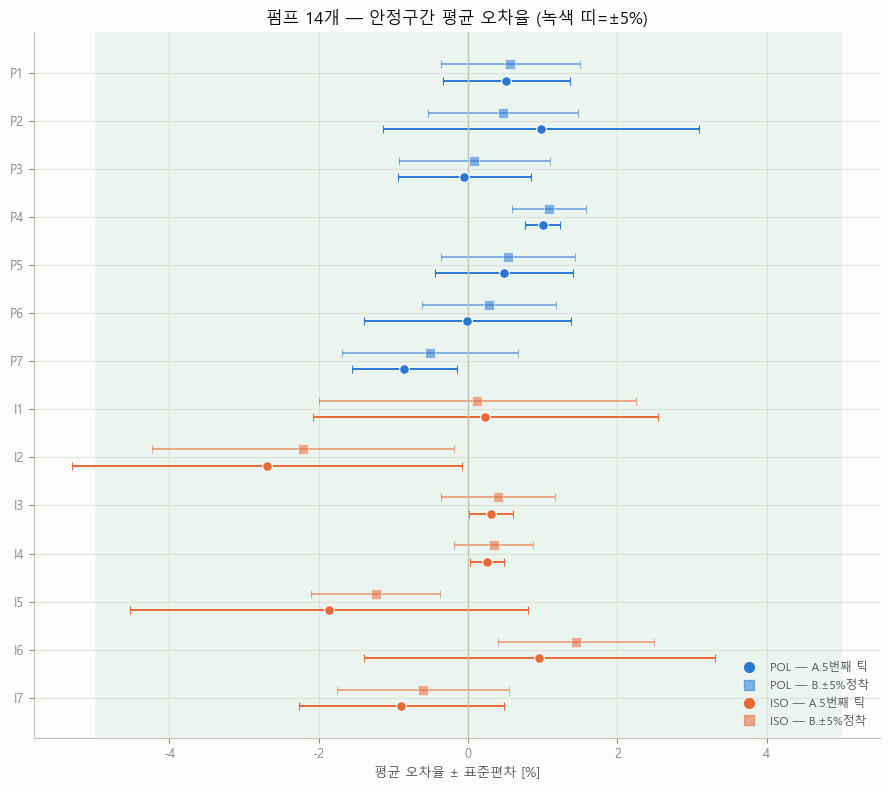

In [27]:
fig, ax = plt.subplots(figsize=(9, 8))
y_labels = []
y = 0
POL_COLOR, ISO_COLOR = BLUE, ORANGE
for pid in ALL_PUMPS:
    d = all_tbl[all_tbl["펌프"] == pid].set_index("정의")
    color = POL_COLOR if pid.startswith("P") else ISO_COLOR
    for j, (defl, marker, dy) in enumerate([("A.5번째 틱", "o", .17), ("B.±5%정착", "s", -.17)]):
        m, s = d.loc[defl, "평균%"], d.loc[defl, "표준편차"]
        alpha = 1.0 if j == 0 else .55
        ax.errorbar(m, y + dy, xerr=s, fmt=marker, color=color, alpha=alpha, ms=7,
                    capsize=3, elinewidth=1.4, mec=SURFACE, mew=.8)
    y_labels.append(pid)
    y += 1
ax.axvline(0, color=AXIS, lw=1)
ax.axvspan(-5, 5, color=AQUA, alpha=.08, lw=0, zorder=0)
ax.set_yticks(range(len(y_labels)), y_labels)
ax.invert_yaxis()
style(ax, xlabel="평균 오차율 ± 표준편차 [%]")
# 범례를 직접 그린다 (errorbar 는 자동 legend 라벨이 지저분해서)
from matplotlib.lines import Line2D
legend_el = [
    Line2D([0], [0], marker="o", color=POL_COLOR, lw=0, ms=7, label="POL — A.5번째 틱"),
    Line2D([0], [0], marker="s", color=POL_COLOR, lw=0, ms=7, alpha=.55, label="POL — B.±5%정착"),
    Line2D([0], [0], marker="o", color=ISO_COLOR, lw=0, ms=7, label="ISO — A.5번째 틱"),
    Line2D([0], [0], marker="s", color=ISO_COLOR, lw=0, ms=7, alpha=.55, label="ISO — B.±5%정착"),
]
ax.legend(handles=legend_el, frameon=False, fontsize=8.5, labelcolor=INK2, loc="lower right")
ax.set_title("펌프 14개 — 안정구간 평균 오차율 (녹색 띠=±5%)", color=INK, fontsize=12)
fig.patch.set_facecolor(SURFACE)
plt.tight_layout(); plt.show()

---## 14. 펌프별 · SV 그룹별 오차율정의는 **A(5번째 틱)** — 실제로 쓸 정의라서 이걸 기준으로 본다. POL 7개, ISO 7개를각각 한 줄에 놓는다.

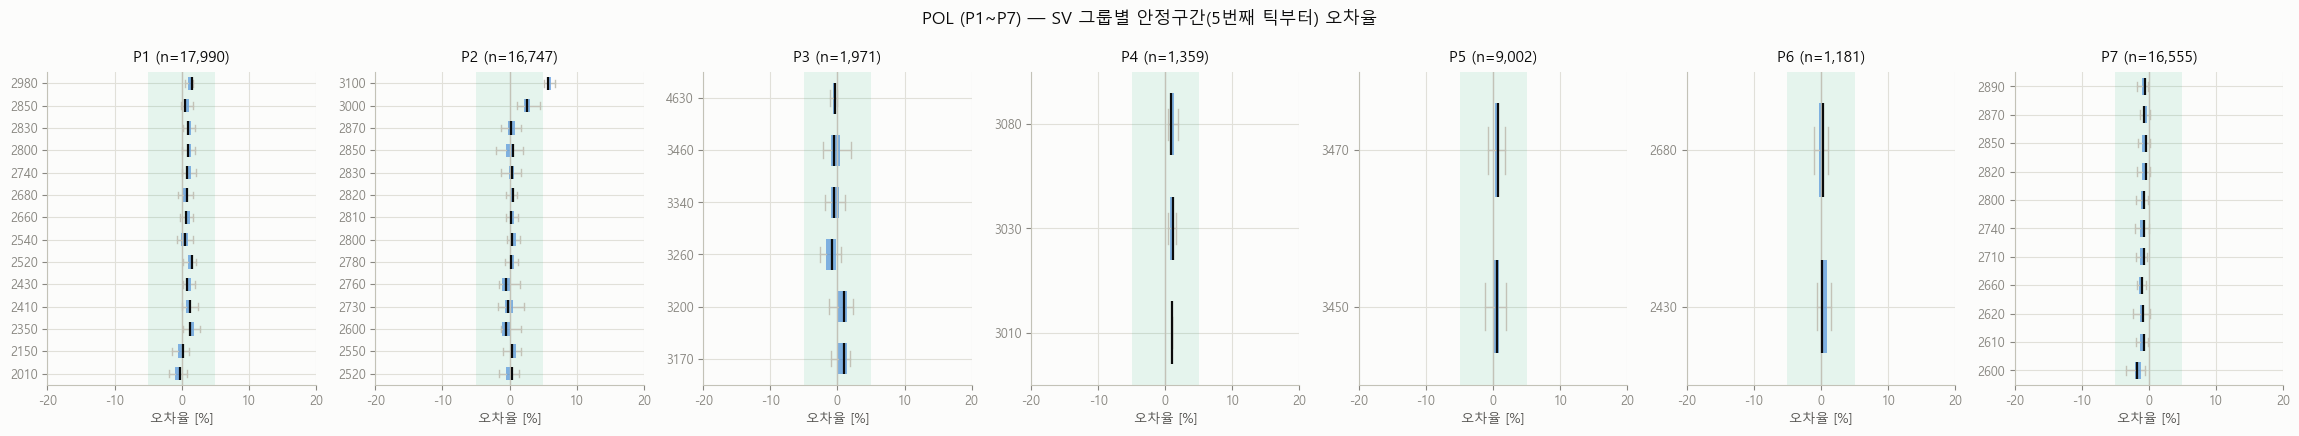

In [28]:
def sv_boxplot_row(pump_list, title):
    fig, axes = plt.subplots(1, len(pump_list), figsize=(3.3 * len(pump_list), 4.4), sharey=False)
    for ax, pid in zip(np.atleast_1d(axes), pump_list):
        tf = frames_all[pid]
        s = tf[tf["Ticks_Since_SV_Change"] >= 4]
        cnt = s["SV"].value_counts()
        levels = sorted(cnt[cnt >= 100].index)
        if not levels:
            ax.text(.5, .5, "표본 부족", ha="center", va="center", color=MUTED, transform=ax.transAxes)
            style(ax, title=f"{pid} (n={len(s):,})")
            continue
        data = [s[s["SV"] == lv]["Err_Pct"].dropna().values for lv in levels]
        bp = ax.boxplot(data, vert=False, patch_artist=True, widths=.6, showfliers=False,
                        medianprops=dict(color=INK, lw=1.6),
                        whiskerprops=dict(color=AXIS), capprops=dict(color=AXIS))
        color = BLUE if pid.startswith("P") else ORANGE
        for patch in bp["boxes"]:
            patch.set_facecolor(color); patch.set_alpha(.55); patch.set_edgecolor("none")
        ax.set_yticks(range(1, len(levels) + 1), [str(int(v)) for v in levels], fontsize=7.5)
        ax.axvline(0, color=AXIS, lw=1)
        ax.axvspan(-5, 5, color=AQUA, alpha=.10, lw=0)
        ax.set_xlim(-20, 20)
        style(ax, title=f"{pid} (n={len(s):,})", xlabel="오차율 [%]")
    fig.suptitle(title, color=INK, fontsize=12.5)
    fig.patch.set_facecolor(SURFACE)
    plt.tight_layout(); plt.show()


sv_boxplot_row([f"P{n}" for n in ALL_PUMP_NUMS], "POL (P1~P7) — SV 그룹별 안정구간(5번째 틱부터) 오차율")

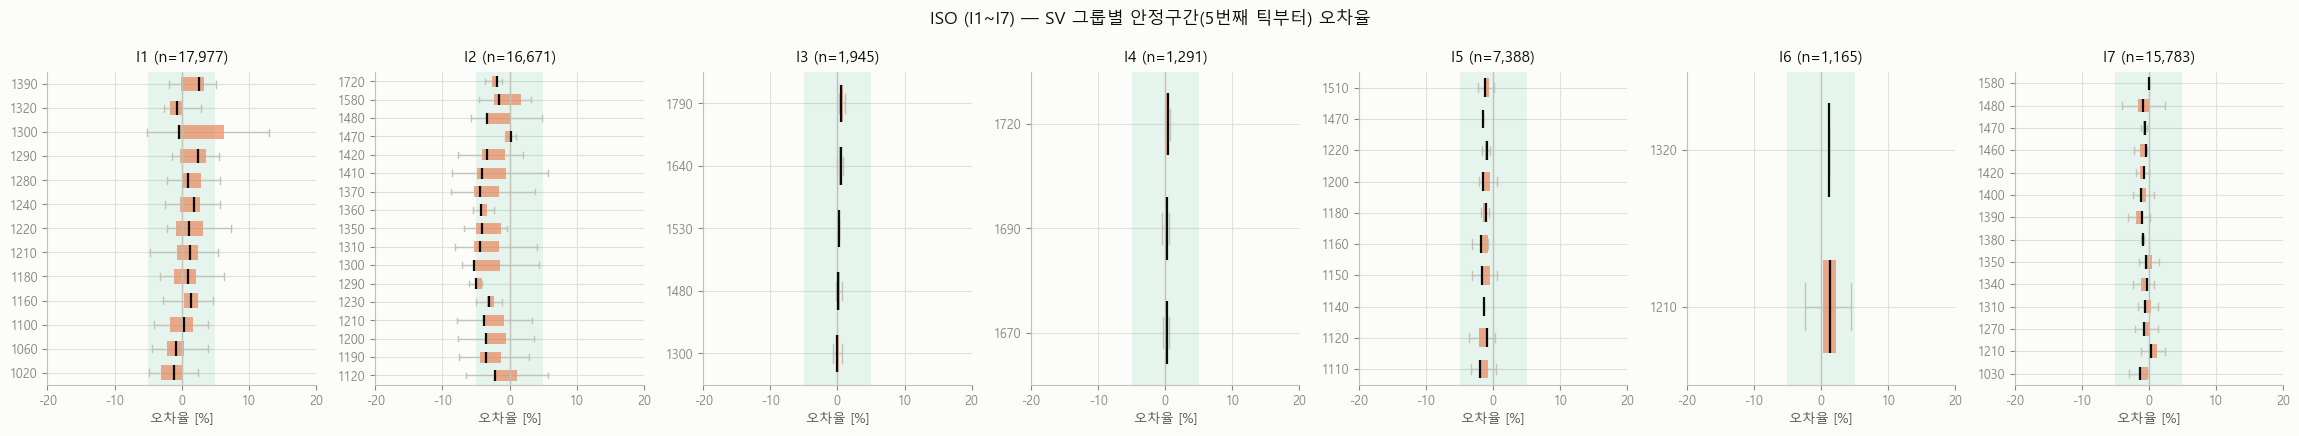

In [29]:
sv_boxplot_row([f"I{n}" for n in ALL_PUMP_NUMS], "ISO (I1~I7) — SV 그룹별 안정구간(5번째 틱부터) 오차율")

**참고**: `n`이 수백 수준인 펌프(P3/P4/P6 계열)는 SV 그룹 하나당 표본이 더 적어서박스가 안 나오거나("표본 부족") 넓게 흔들릴 수 있다 — 가동량 자체가 적은 펌프라그런 것이고, 기준을 잘못 잡았다는 뜻은 아니다.